In [6]:
import numpy as np
import pandas as pd
import os

DATA_DIR = os.path.join(os.getcwd(), "Embedding", "6")

In [7]:
# ── Load data hasil augmentasi Mixup ─────────────────────────────────────────
questions_emb  = np.load(os.path.join(DATA_DIR, 'questions_emb.npy'))
answerkeys_emb = np.load(os.path.join(DATA_DIR, 'answerkeys_emb.npy'))
answers_emb    = np.load(os.path.join(DATA_DIR, 'answers_emb.npy'))
metadata       = pd.read_pickle(os.path.join(DATA_DIR, 'metadata.pkl'))
metadata       = metadata.reset_index(drop=True)
metadata['is_synthetic'] = False  # tandai data asli

print("=== Hasil Load ===")
print(f"questions_emb  : {questions_emb.shape}")
print(f"answerkeys_emb : {answerkeys_emb.shape}")
print(f"answers_emb    : {answers_emb.shape}")
print(f"Metadata       : {len(metadata)} rows")

=== Hasil Load ===
questions_emb  : (17, 135, 300)
answerkeys_emb : (17, 90, 300)
answers_emb    : (1229, 85, 300)
Metadata       : 1229 rows


In [9]:
# ── Analisis lubang (grade = 0 sampel per IDPSJ) ──────────────────────────────
pivot = (metadata.groupby(['IDPSJ', 'grade'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi sebelum Cross-Prompt Injection:")
print(pivot.to_string())

# Daftar lubang: (IDPSJ_target, grade)
holes = [(psj, g)
         for psj in pivot.index
         for g in range(1, 11)
         if pivot.loc[psj, g] == 0]

print(f"\nTotal lubang (grade=0): {len(holes)}")
for h in holes:
    print(f"  IDPSJ {h[0]:>2}  grade {h[1]}")

Distribusi sebelum Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       1   1   0   4   1  25   3  11   5  37
2       0   0  15   0   5   5   0  10   0   5
3       0   0   0   4   1  10   0   6   0   7
4       0   5   5  15   1   9   8   0   3  17
5       0   4   7   0   5   5   2   3   5   5
6       0   4   4   5   5  10   5   3   3   7
7       0   0   3   0   8  10   4   6   3  17
8       0   0  12   6  11   7   3  10  10  53
9      13   0   9   9   1  10  10   2   1  47
10      3   8   0  10   0  10  18  23  18  21
11      0   0   0   0  10   0   0   0   0  22
12      4   0   0   0   0   0   0   3   3   2
13      5   1   0   2   3   6   0   7   2   6
14      8   2   0   5   2   6   5   8   3   7
15      1   5   9   9   1  10   1   9   0  10
16      0   0   0   0   4   0   0   0   0   3
17      0   0   0   2   7   2   1   2   1   6

Total lubang (grade=0): 53
  IDPSJ  1  grade 3
  IDPSJ  2  grade 1
  IDPSJ  2  gra

In [17]:
# ── Cross-Prompt Injection ────────────────────────────────────────────────────
# Strategi:
#   Untuk setiap lubang (IDPSJ_target, grade_target):
#   1. Hitung target = ceil(max_cls_IDPSJ / 2)  → konsisten dengan Mixup
#   2. Cari donor: IDPSJ lain yang PUNYA grade_target
#   3. Ambil (target) answer embeddings dari donor (acak, dengan penggantian)
#   4. Pasangkan dengan question & answerkey milik IDPSJ_target (diambil via IDPSJ index)
#   5. Label tetap = grade_target

RNG = np.random.default_rng(seed=42)

inj_answers = []
inj_meta    = []

for (tgt_psj, tgt_grade) in holes:
    # Target per kelas = ceil(max kelas IDPSJ ini / 2)  — sama dengan Mixup
    local_max = pivot.loc[tgt_psj].max()
    n_inject  = int(np.ceil(local_max / 2))

    # Indeks IDPSJ ke questions_emb / answerkeys_emb (0-indexed, IDPSJ mulai dari 1)
    # questions_emb.shape = (17, seq, 300) → satu baris per IDPSJ
    tgt_rep_idx = tgt_psj - 1

    # Cari donor: IDPSJ lain yang punya grade_target
    donor_mask = (
        (metadata['IDPSJ'] != tgt_psj) &
        (metadata['grade'] == tgt_grade)
    )
    donor_idx = metadata.index[donor_mask].values

    if len(donor_idx) == 0:
        print(f"  [SKIP] IDPSJ={tgt_psj} grade={tgt_grade} — tidak ada donor!")
        continue

    print(f"  IDPSJ={tgt_psj} grade={tgt_grade}  target={n_inject}  donor={len(donor_idx)}")

    # Ambil n_inject sampel dari donor (dengan penggantian jika donor sedikit)
    sampled = RNG.choice(donor_idx, size=n_inject, replace=len(donor_idx) < n_inject)

    # Hanya answers yang diambil dari donor; questions & answerkeys tetap per IDPSJ
    inj_answers.append(answers_emb[sampled])

    for k in range(n_inject):
        inj_meta.append({
            'IDJwb'        : f'cpi_{tgt_psj}_{tgt_grade}_{k}',
            'IDPSJ'        : tgt_psj,
            'grade'        : tgt_grade,
            'is_synthetic' : True,
        })

# ── Gabungkan ─────────────────────────────────────────────────────────────────
if inj_answers:
    final_answers_emb = np.vstack([answers_emb] + inj_answers)
    final_metadata    = pd.concat([metadata, pd.DataFrame(inj_meta)],
                                  ignore_index=True)
else:
    final_answers_emb = answers_emb.copy()
    final_metadata    = metadata.copy()

# questions & answerkeys tidak diubah — sudah satu baris per IDPSJ
final_questions_emb  = questions_emb   # (17, 135, 300)
final_answerkeys_emb = answerkeys_emb  # (17, 90, 300)

n_inj = len(final_metadata) - len(metadata)
print(f"\nData sebelum CPI : {len(metadata)}")
print(f"Data injeksi CPI : {n_inj}")
print(f"Total akhir      : {len(final_metadata)}")
print(f"\nfinal_answers_emb    : {final_answers_emb.shape}")
print(f"final_questions_emb  : {final_questions_emb.shape}")
print(f"final_answerkeys_emb : {final_answerkeys_emb.shape}")

  IDPSJ=1 grade=3  target=19  donor=84
  IDPSJ=2 grade=2  target=8  donor=78
  IDPSJ=2 grade=4  target=8  donor=90
  IDPSJ=2 grade=7  target=8  donor=103
  IDPSJ=2 grade=9  target=8  donor=69
  IDPSJ=3 grade=2  target=5  donor=78
  IDPSJ=3 grade=3  target=5  donor=84
  IDPSJ=3 grade=7  target=5  donor=103
  IDPSJ=3 grade=9  target=5  donor=69
  IDPSJ=4 grade=1  target=9  donor=150
  IDPSJ=4 grade=8  target=9  donor=154
  IDPSJ=5 grade=4  target=9  donor=90
  IDPSJ=7 grade=2  target=9  donor=78
  IDPSJ=7 grade=4  target=9  donor=90
  IDPSJ=8 grade=1  target=27  donor=150
  IDPSJ=8 grade=2  target=27  donor=78
  IDPSJ=9 grade=2  target=24  donor=78
  IDPSJ=10 grade=3  target=12  donor=84
  IDPSJ=10 grade=5  target=12  donor=70
  IDPSJ=11 grade=4  target=21  donor=90
  IDPSJ=11 grade=6  target=21  donor=152
  IDPSJ=11 grade=9  target=21  donor=69
  IDPSJ=12 grade=2  target=11  donor=78
  IDPSJ=12 grade=4  target=11  donor=90
  IDPSJ=12 grade=6  target=11  donor=152
  IDPSJ=13 grade=3  tar

Distribusi setelah Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       9   1  19   9   1  25   3  11   5  37
2       1   8  15   8   5   5   8  10   8   5
3       5   5   5   4   1  10   5   6   5   7
4       9   5   5  15   1  10  10   9   3  17
5      17   4   7   9   5   5   2   3   5   5
6      22   4   4   5   5  10   5   5   4   7
7       6   9   3   9   8  10   4   6   3  17
8      27  27  12   6  11   7   3  10  10  53
9      14  24   9   9   1  10  10   2   1  47
10      5   8  12  10  12  10  18  23  19  21
11      6  42  17  21  10  21  13  10  21  22
12      4  11   1  11   5  11  21   6   6   2
13      9   1  10   6   3  11  10  20   2   8
14      9   2   8   6   2  12   5  15   3   9
15     11   5   9   9   1  10   1   9   6  10
16      5   4   2   8   4   8   5  10   7   3
17     27   2  14   3   7   9   3   8   1   9

Sisa lubang setelah CPI: 0


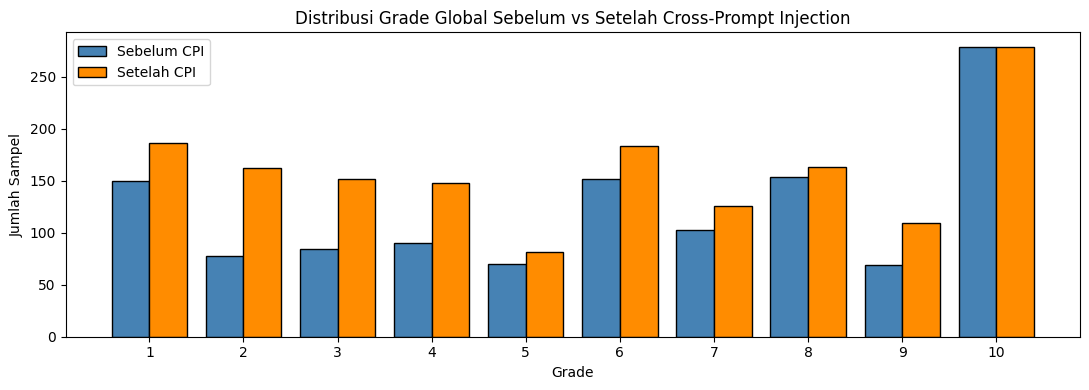

In [18]:
# ── Verifikasi distribusi setelah CPI ─────────────────────────────────────────
import matplotlib.pyplot as plt

pivot_final = (final_metadata.groupby(['IDPSJ', 'grade'])
                             .size()
                             .unstack(fill_value=0)
                             .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi setelah Cross-Prompt Injection:")
print(pivot_final.to_string())

sisa_holes = [(psj, g)
              for psj in pivot_final.index
              for g in range(1, 11)
              if pivot_final.loc[psj, g] == 0]
print(f"\nSisa lubang setelah CPI: {len(sisa_holes)}")
if sisa_holes:
    for h in sisa_holes:
        print(f"  IDPSJ={h[0]} grade={h[1]} — tidak ada donor di seluruh dataset")

# Bar chart distribusi global sebelum vs sesudah
before = metadata['grade'].value_counts().sort_index()
after  = final_metadata['grade'].value_counts().sort_index()

x = np.arange(1, 11)
w = 0.4
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, [before.get(g, 0) for g in x], w, label='Sebelum CPI', color='steelblue',  edgecolor='black')
ax.bar(x + w/2, [after.get(g,  0) for g in x], w, label='Setelah CPI', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xlabel('Grade')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Grade Global Sebelum vs Setelah Cross-Prompt Injection')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Simpan hasil akhir ───────────────────────────────────────────────────────
# answers_emb : simpan penuh karena setiap sampel unik
# questions & answerkeys : satu baris per IDPSJ (tidak berubah setelah CPI)
#   → rekonstruksi di training menggunakan kolom psj_idx di metadata

# Buat mapping IDPSJ → indeks unik (harus konsisten dengan urutan questions_emb)
idpsj_sorted  = sorted(final_metadata['IDPSJ'].unique())
idpsj_to_idx  = {psj: i for i, psj in enumerate(idpsj_sorted)}
final_metadata = final_metadata.copy()
final_metadata['psj_idx'] = final_metadata['IDPSJ'].map(idpsj_to_idx)

# Simpan
np.save(os.path.join(DATA_DIR, 'final_answers_emb.npy'),    final_answers_emb)
np.save(os.path.join(DATA_DIR, 'final_questions_emb.npy'),  final_questions_emb)
np.save(os.path.join(DATA_DIR, 'final_answerkeys_emb.npy'), final_answerkeys_emb)
final_metadata.to_pickle(os.path.join(DATA_DIR, 'final_metadata.pkl'))

print("File tersimpan:")
print(f"  final_answers_emb.npy      {final_answers_emb.shape}  (per sampel)")
print(f"  final_questions_emb.npy    {final_questions_emb.shape}  (per IDPSJ)")
print(f"  final_answerkeys_emb.npy   {final_answerkeys_emb.shape}  (per IDPSJ)")
print(f"  final_metadata.pkl         {len(final_metadata)} rows  (+ kolom psj_idx)")

File tersimpan:
  final_answers_emb.npy      (1591, 85, 300)  (per sampel)
  final_questions_emb.npy    (17, 135, 300)  (per IDPSJ)
  final_answerkeys_emb.npy   (17, 90, 300)  (per IDPSJ)
  final_metadata.pkl         1591 rows  (+ kolom psj_idx)
